---
title: "Lab 4"
format: 
    html:
        embed-resources: true
code-fold: true
echo: true
---

In [ ]:
import re
import pandas as pd
from bs4 import BeautifulSoup
import requests
URL = "https://tastesbetterfromscratch.com/meal-plan-210/"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

response = requests.get(URL, headers=HEADERS)
soup = BeautifulSoup(response.content, "html.parser")

In [ ]:
page = soup.find("article") or soup
page

<article class="type-post grow-content-body"><div class="entry-content"><div class="dpsp-content-wrapper dpsp-shape-rectangular dpsp-size-medium dpsp-has-spacing dpsp-no-labels-mobile dpsp-hide-on-mobile dpsp-button-style-6" id="dpsp-content-top" style="min-height:40px;position:relative">
<ul class="dpsp-networks-btns-wrapper dpsp-networks-btns-share dpsp-networks-btns-content dpsp-column-auto dpsp-has-button-icon-animation" style="padding:0;margin:0;list-style-type:none">
<li class="dpsp-network-list-item dpsp-network-list-item-facebook" style="float:left">
<a aria-label="Share on Facebook" class="dpsp-network-btn dpsp-facebook dpsp-first dpsp-has-label dpsp-has-label-mobile" href="https://www.facebook.com/sharer/sharer.php?u=https%3A%2F%2Ftastesbetterfromscratch.com%2Fmeal-plan-210%2F&amp;t=Meal%20Plan%20%28210%29" rel="nofollow noopener" style="font-size:14px;padding:0rem;max-height:40px" target="_blank" title="Share on Facebook"> <span class="dpsp-network-icon"><span class="dpsp-ne

In [ ]:
# Data from unstructured websites
rows = []

for p in page.find_all("p"):

    text = p.get_text(" ", strip=True)
    day_of_week = re.findall(r"^\s*(Monday|Tuesday|Wednesday|Thursday|Friday)", text)
    if not day_of_week:
      continue

    a_tag = p.find("a", href=True)
    if not a_tag:
      continue

    dow = day_of_week[0]
    nor = a_tag.get_text(strip=True)
    ltr = a_tag["href"]

    price_of_recipe = re.findall(r"\$\d+", text)
    por = price_of_recipe[0]

    rows.append({
        "Day of the Week": dow,
        "Name of Recipe": nor,
        "Link to Recipe": ltr,
        "Price of Recipe": por
    })
rows
df = pd.DataFrame(rows)
df

,Day of the Week,Name of Recipe,Link to Recipe,Price of Recipe
0,Monday,Biscuit Chicken Pot Pie,https://tastesbetterfromscratch.com/biscuit-ch...,$11
1,Tuesday,Calzone,https://tastesbetterfromscratch.com/calzones/,$8
2,Wednesday,Quinoa Burger,https://tastesbetterfromscratch.com/quinoa-veg...,$15
3,Thursday,Short Rib Ragu,https://tastesbetterfromscratch.com/short-rib-...,$26
4,Friday,Cabbage Roll Soup,https://tastesbetterfromscratch.com/cabbage-ro...,$20


In [ ]:
# Data from an API
url = "https://tasty.p.rapidapi.com/recipes/list"

querystring = {"from":"0","size":"100","q":"Biscuit Chicken Pot Pie"}

headers = {
    "X-RapidAPI-Key": "4f85e5e122msh63a4df4681857e4p1a4f4djsn7c6f75bc2489",
    "X-RapidAPI-Host": "tasty.p.rapidapi.com"
}

response = requests.get(url, headers=headers, params=querystring)

print(response.json())

{'count': 7, 'results': [{'approved_at': 1550254399, 'aspect_ratio': '1:1', 'beauty_url': None, 'brand': None, 'brand_id': None, 'buzz_id': None, 'canonical_id': 'recipe:4780', 'compilations': [{'approved_at': 1574970935, 'aspect_ratio': '1:1', 'beauty_url': None, 'buzz_id': None, 'canonical_id': 'compilation:1274', 'country': 'US', 'created_at': 1574837986, 'description': None, 'draft_status': 'published', 'facebook_posts': [], 'id': 1274, 'is_shoppable': False, 'keywords': None, 'language': 'eng', 'name': '4 Delicious Pot Pie Recipes You Cannot Resist ', 'promotion': 'full', 'show': [{'id': 17, 'name': 'Tasty'}], 'slug': '4-delicious-pot-pie-recipes-you-cannot-resist', 'thumbnail_alt_text': '', 'thumbnail_url': 'https://img.buzzfeed.com/thumbnailer-prod-us-east-1/video-api/assets/245046.jpg', 'video_id': 96050, 'video_url': 'https://vid.tasty.co/output/153023/hls24_1574838106.m3u8'}, {'approved_at': 1600780962, 'aspect_ratio': '1:1', 'beauty_url': None, 'buzz_id': None, 'canonical_id

In [ ]:
pot_pie_recipes = pd.json_normalize(response.json(), "results")
pot_pie_recipes['name']

,name
0,Cheddar Biscuit Chicken Pot Pie
1,Turkey Skillet Pot Pie With Buttermilk Biscuits
2,Semi-Homemade Veggie-Packed Pot Pie 2 Ways
3,Chicken Cobbler Pot Pie Hack
4,Ham And Biscuit Pot Pie
5,Leftover Turkey Pot Pie
6,Recipes For When You're In The Mood For Love


In [ ]:
# Automate it
def get_weekly_plan(plan_num):
  if not (100 <= int(plan_num) <= 210):
    raise ValueError("Weekly meal plan number must be between 100 and 210")

  url = f"https://tastesbetterfromscratch.com/meal-plan-{plan_num}/"
  response = requests.get(url, headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"})
  soup = BeautifulSoup(response.content, "html.parser")
  page = soup.find("article") or soup

  rows = []

  for p in page.find_all("p"):

    text = p.get_text(" ", strip=True)
    day_of_week = re.findall(r"^\s*(Monday|Tuesday|Wednesday|Thursday|Friday)", text)
    if not day_of_week:
      continue

    a_tag = p.find("a", href=True)
    if not a_tag:
      continue

    dow = day_of_week[0]
    nor = a_tag.get_text(strip=True)
    ltr = a_tag["href"]

    price_of_recipe = re.findall(r"\$\d+", text)
    por = price_of_recipe[0]

    rows.append({
        "Day of the Week": dow,
        "Name of Recipe": nor,
        "Link to Recipe": ltr,
        "Price of Recipe": por
    })
  df = pd.DataFrame(rows)
  if not df.empty:
    df["weekday_order"] = df["Day of the Week"].map({
        "Monday": 1,
        "Tuesday": 2,
        "Wednesday": 3,
        "Thursday": 4,
        "Friday": 5
    })
    return df

In [ ]:
df2 = get_weekly_plan(210)
df2

,Day of the Week,Name of Recipe,Link to Recipe,Price of Recipe,weekday_order
0,Monday,Biscuit Chicken Pot Pie,https://tastesbetterfromscratch.com/biscuit-ch...,$11,1
1,Tuesday,Calzone,https://tastesbetterfromscratch.com/calzones/,$8,2
2,Wednesday,Quinoa Burger,https://tastesbetterfromscratch.com/quinoa-veg...,$15,3
3,Thursday,Short Rib Ragu,https://tastesbetterfromscratch.com/short-rib-...,$26,4
4,Friday,Cabbage Roll Soup,https://tastesbetterfromscratch.com/cabbage-ro...,$20,5


In [ ]:
def match_recipe(recipe_name):

  url = "https://tasty.p.rapidapi.com/recipes/list"
  querystring = {"from":"0","size":"100","q":recipe_name}

  headers = {
    "X-RapidAPI-Key": "4f85e5e122msh63a4df4681857e4p1a4f4djsn7c6f75bc2489",
    "X-RapidAPI-Host": "tasty.p.rapidapi.com"
  }

  response = requests.get(url, headers=headers, params=querystring)

  data = response.json()
  recipe_names = pd.json_normalize(data.get("results", []))

  columns = [
      "name","num_servings", "nutrition.calories","nutrition.fat","nutrition.carbohydrates","nutrition.protein","nutrition.sugar","nutrition.fiber"
  ]
  columns = [c for c in columns if c in recipe_names.columns]
  return recipe_names[columns] if columns else recipe_names

In [ ]:
recipe_match = match_recipe("Baked Salmon")
recipe_match

,name,num_servings,nutrition.calories,nutrition.fat,nutrition.carbohydrates,nutrition.protein,nutrition.sugar,nutrition.fiber
0,Puff Pastry Salmon (Salmon Wellington),2,898.0,61.0,55.0,31.0,6.0,4.0
1,Honey Soy-Glazed Salmon,2,525.0,25.0,34.0,36.0,32.0,0.0
2,One-Pan Salmon And Veggies,2,730.0,24.0,93.0,34.0,4.0,8.0
3,One-Pan Lemon Herb Salmon & Veggies,4,311.0,17.0,9.0,27.0,6.0,2.0
4,One-Pan Garlic Butter Salmon,4,402.0,31.0,18.0,15.0,3.0,7.0
5,Avocado Lime Salmon,1,719.0,55.0,18.0,37.0,2.0,11.0
6,Maple-Glazed Salmon,2,466.0,27.0,40.0,18.0,22.0,7.0
7,Parmesan Crusted Salmon,1,708.0,42.0,28.0,53.0,3.0,4.0
8,Parchment Garlic Butter Salmon,1,895.0,56.0,54.0,39.0,2.0,4.0
9,Tomato Pesto Salmon,1,738.0,55.0,18.0,44.0,10.0,5.0


In [ ]:
def get_mealplan_data(plan_num):
  meal_df = get_weekly_plan(plan_num)

  all_rows = []
  for _, row in meal_df.iterrows():
    recipe_name = row["Name of Recipe"]
    recipe_match = match_recipe(recipe_name)

    if recipe_match.empty:
      d = row.to_dict()
      for tasty in ["name","num_servings", "nutrition.calories","nutrition.fat","nutrition.carbohydrates","nutrition.protein","nutrition.sugar","nutrition.fiber"]:
        d["tasty_" + tasty] = ""
      all_rows.append(d)
    else:
      m = recipe_match.add_prefix("tasty_")
      for _, mrecipe_row in m.iterrows():
        d = row.to_dict()
        d.update(mrecipe_row.to_dict())
        all_rows.append(d)
  df = pd.DataFrame(all_rows)
  return df

In [ ]:
df = get_mealplan_data(202)
df

,Day of the Week,Name of Recipe,Link to Recipe,Price of Recipe,weekday_order,tasty_name,tasty_num_servings,tasty_nutrition.calories,tasty_nutrition.fat,tasty_nutrition.carbohydrates,tasty_nutrition.protein,tasty_nutrition.sugar,tasty_nutrition.fiber
0,Monday,Chicken Divan,https://tastesbetterfromscratch.com/skinny-chi...,$10,1,,,,,,,,
1,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,Taiwanese Beef Noodle Soup,6,887.0,33.0,81.0,68.0,15.0,9.0
2,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,Classic Lasagna Soup,4,697.0,31.0,44.0,50.0,10.0,3.0
3,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,Traditional Vietnamese Beef Pho,8,539.0,20.0,59.0,27.0,3.0,3.0
4,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,1-Day Noodles (Taiwanese Beef Noodle Soup),8,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,5 Fork-less Finger Foods,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,Homemade American Street Foods,NaN,NaN,NaN,NaN,NaN,NaN,NaN
79,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,Chicken Recipes For The Whole Month,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,Tasty Dinners for Every Night of December,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Add a column with fuzzy matching
meats = re.compile(r"\b(chicken|beef|pork|turkey|lamb|bacon|steak|ham|sausage|meatball|fish|salmon|chorizo|tuna|shrimp)\b", flags=re.I)
title = (
    df["tasty_name"].where(df["tasty_name"].astype(str).str.len() > 0, df["Name of Recipe"])
    if "tasty_name" in df.columns else df["Name of Recipe"]
).fillna("")

df["vegetarian"] = ~title.str.contains(meats)
df

/tmp/ipython-input-2586492342.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.


,Day of the Week,Name of Recipe,Link to Recipe,Price of Recipe,weekday_order,tasty_name,tasty_num_servings,tasty_nutrition.calories,tasty_nutrition.fat,tasty_nutrition.carbohydrates,tasty_nutrition.protein,tasty_nutrition.sugar,tasty_nutrition.fiber,vegetarian
0,Monday,Chicken Divan,https://tastesbetterfromscratch.com/skinny-chi...,$10,1,,,,,,,,,False
1,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,Taiwanese Beef Noodle Soup,6,887.0,33.0,81.0,68.0,15.0,9.0,False
2,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,Classic Lasagna Soup,4,697.0,31.0,44.0,50.0,10.0,3.0,True
3,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,Traditional Vietnamese Beef Pho,8,539.0,20.0,59.0,27.0,3.0,3.0,False
4,Tuesday,Beef Noodle Soup,https://tastesbetterfromscratch.com/beef-noodl...,$29,2,1-Day Noodles (Taiwanese Beef Noodle Soup),8,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,5 Fork-less Finger Foods,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
78,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,Homemade American Street Foods,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
79,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,Chicken Recipes For The Whole Month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
80,Friday,Chicken Gyros,https://tastesbetterfromscratch.com/chicken-gy...,$21,5,Tasty Dinners for Every Night of December,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


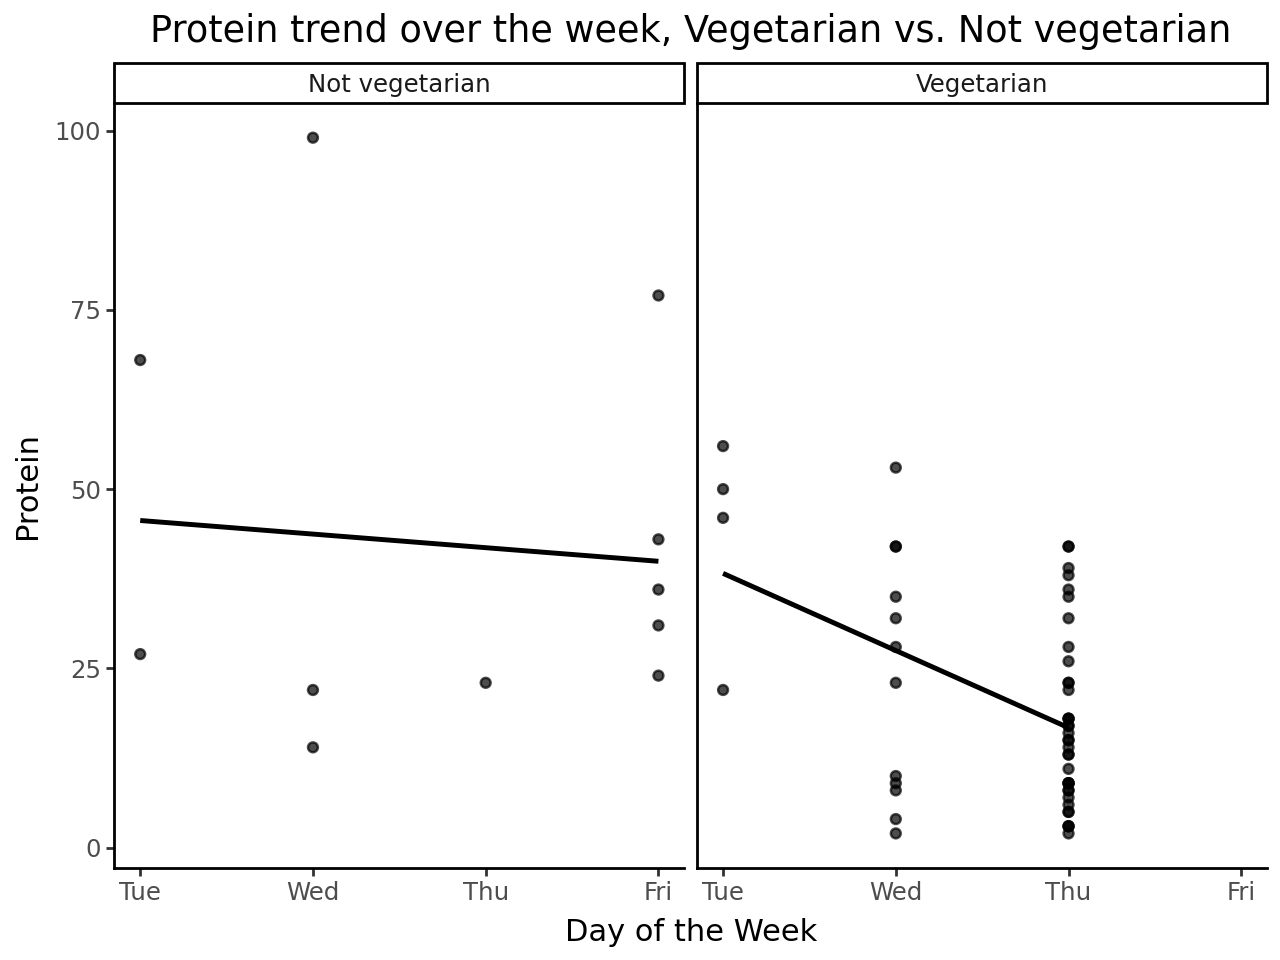

In [ ]:
# Analyze
import plotnine
from plotnine import ggplot, aes, geom_point, stat_smooth, facet_wrap, labs, theme_classic, scale_x_continuous

plot_df = df.copy()
plot_df["protein"] = pd.to_numeric(plot_df["tasty_nutrition.protein"], errors="coerce")
plot_df = plot_df.dropna(subset=["protein"])
plot_df["veg_label"] = plot_df["vegetarian"].map({True: "Vegetarian", False: "Not vegetarian"})

plot = (
    ggplot(plot_df, aes(x="weekday_order", y="protein"))
    + geom_point(alpha=0.7)
    + stat_smooth(method="lm", se=False)
    + facet_wrap("~veg_label")
    + scale_x_continuous(breaks=[1,2,3,4,5],labels=["Mon","Tue","Wed","Thu","Fri"])
    + labs(title="Protein trend over the week, Vegetarian vs. Not vegetarian", x="Day of the Week", y="Protein")
    + theme_classic()
)
plot

The story that this visualization tells is that non-vegetarian recipes tend to have higher and more consistent amounts of protein throughout the week compared to vegetarian recipes.